# Titanic: Machine Learning from Disaster
### Predict survival on the Titanic
- Defining the problem statement
- Collecting the data
- Exploratory data analysis (EDA)
- Feature engineering
- Modelling
- Testing

## 1_1.Defining the problem statement
Complete the analysis of what sorts of people were likely to survive.
In particular, we ask you to apply the tools of machine learning to predict which passengers survived the Titanic tragedy.

In [193]:
from IPython.display import Image
Image(url= "https://static1.squarespace.com/static/5006453fe4b09ef2252ba068/5095eabce4b06cb305058603/5095eabce4b02d37bef4c24c/1352002236895/100_anniversary_titanic_sinking_by_esai8mellows-d4xbme8.jpg")

# 1_2.Collecting the data(데이터 수집)

In [194]:
import pandas as pd

In [195]:
train=pd.read_csv('../data/train.csv') # 891
test= pd.read_csv('../data/test.csv') # 418

# 1_3.Exploratory data analysis(탐색적 데이터 분석)

In [196]:
train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data dictionary
- Survived(생존여부) : 0=No, 1=Yes
- Pclass(객실등급) : Ticket class  1=1st  2=2st 3=3st
- sibsp(형제/자매 및 배우자) :  soblingd / spouses ablout the Titanic
- parch(부모/자녀) :  parents / children ablout the Titanic
- ticket(티켓 번호) : Ticket number
- cabin(객실 번호) : Cabin number
- embarked(승선 항구) : Port of Embarkation C=Cherbourg, Q=Queenstown, S=Southampton

In [197]:
test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


**Total rows and columns**

We can see that there are 891 rows and 12 columns in our training dataset.

In [198]:
train.shape

(891, 12)

In [199]:
test.shape

(418, 11)

In [200]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [201]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


We can see that Age value is missing for many rows.

Out of 891 rows, the Age value is present only in 714 rows.

Similarly, Cabin values are also missing in many rows. Only 204 out of 891 rows have Cabin values.

In [202]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [203]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [204]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

# Bar Chart for Categorical Features
- Pclass
- Sex
- SibSp
- Parch
- Embarked
- Cabin

In [205]:
def bar_chart(feature):
    survived = train[train["Survived"] ==1][feature].value_counts()
    dead = train[train["Survived"] ==0][feature].value_counts()
    df= pd.DataFrame([survived,dead])
    df.index=(['Survived','Dead'])
    df.plot(kind='bar', stacked=True, figsize=(10,5))


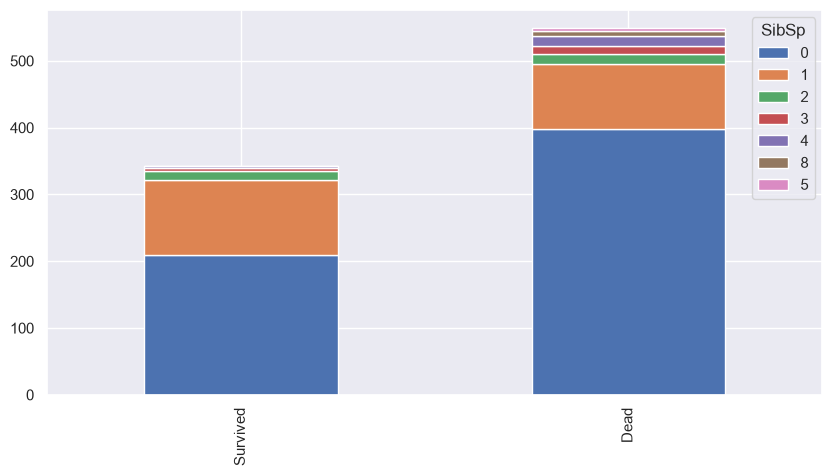

In [206]:
bar_chart('SibSp')

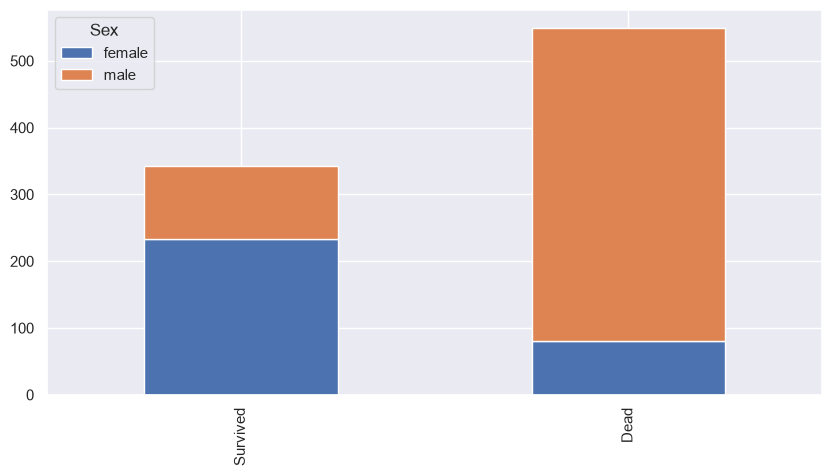

In [207]:
bar_chart('Sex')

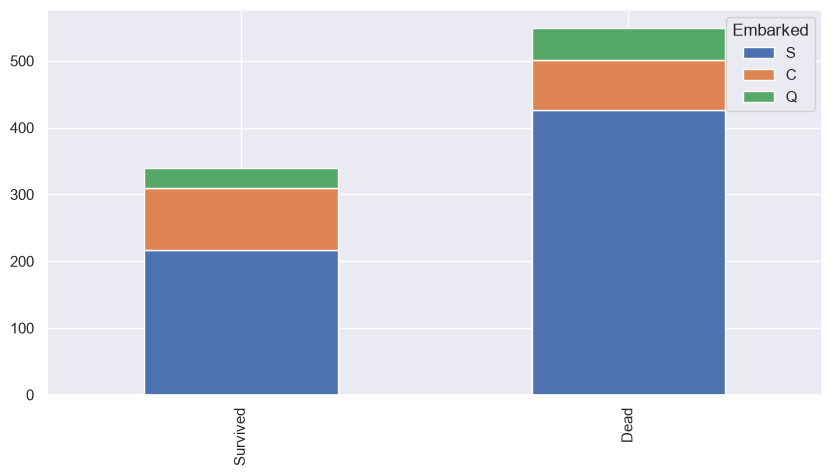

In [208]:
bar_chart('Embarked')

## 3.Feature engineering
Feature engineering is the process of using domain knowledge of the data
to create features (**feature vectors**) that make machine learning algorithms work.

feature vector is an n-dimensional vector of numerical features that represent some object.
Many algorithms in machine learning require a numerical representation of objects,
since such representations facilitate processing and statistical analysis.

# 3-1. how titanic sank?

sank from the bow of the ship where third class rooms located conclusion, Pclass is key feature for classifier

In [209]:
Image(url= "https://static1.squarespace.com/static/5006453fe4b09ef2252ba068/t/5090b249e4b047ba54dfd258/1351660113175/TItanic-Survival-Infographic.jpg?format=1500w")

## 3-2 Name


In [210]:
train_test_data = [train,test] # train, test data combining
# expand=False: Series 형태로 변환
for dataset in train_test_data:
    dataset['Title']=dataset['Name'].str.extract('([A-Za-z]+)\.', expand=False)


<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_96494/4195519288.py:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  dataset['Title']=dataset['Name'].str.extract('([A-Za-z]+)\.', expand=False)


In [211]:
train['Title'].value_counts()


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [212]:
test['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [213]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Title        891 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 90.6 KB


In [214]:
# 1,2,3과 매핑
title_mapping = {
"Mr": 0, "Miss": 1, "Mrs": 2,
"Master": 3, "Dr": 3, "Rev": 3, "Col": 3, "Major": 3, "Mlle": 3,"Countess": 3,
"Ms": 3, "Lady": 3, "Jonkheer": 3, "Don": 3, "Dona" : 3, "Mme": 3,"Capt": 3,"Sir": 3
}

# 전처리된 'Title' 컬럼을 매핑하여 생성

for dataset in train_test_data:
    dataset['Title'] = dataset['Title'].map(title_mapping)

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


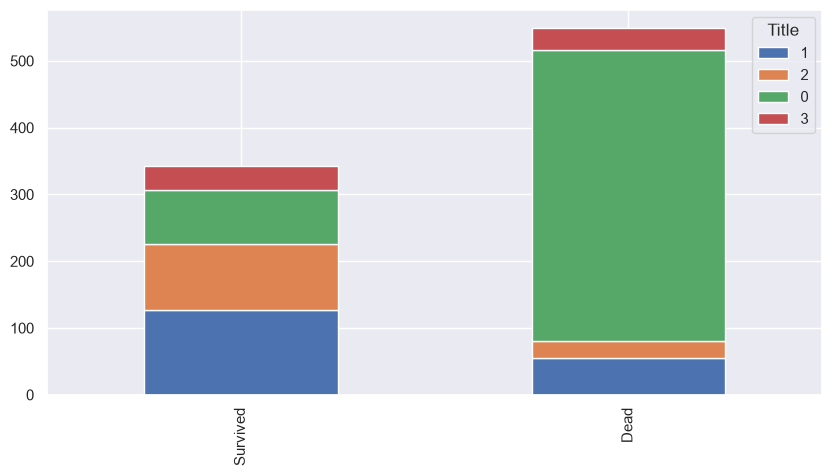

In [215]:
bar_chart('Title')

In [216]:
# delete feature from dataset
# axis=1 (열단위), inplace=True : 원본에서도 삭제
train.drop('Name', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)

## 3-3 Sex
- male:0, female:1

In [217]:
sex_mapping = {
    "male":0,
    "female":1
}
for data in train_test_data:
    data['Sex'] = data['Sex'].map(sex_mapping)

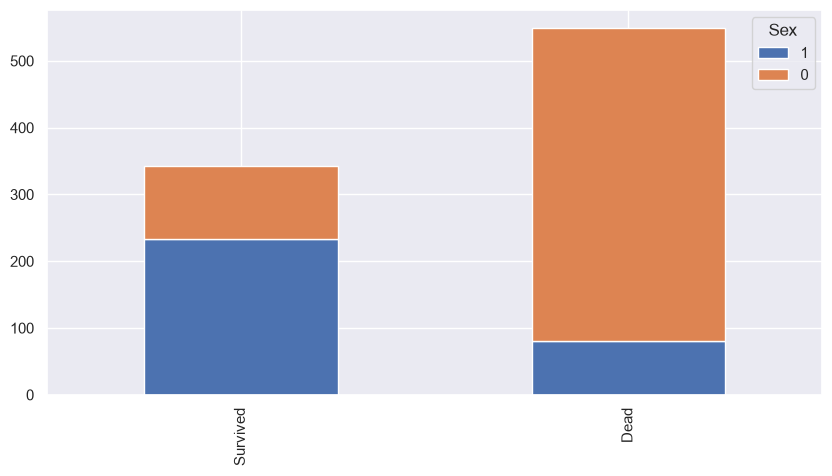

In [218]:
bar_chart('Sex')

### 4.3 Age
* some age is missing
* Let's use Title's median age for missing Age
* feature scaling

In [219]:
# Age값의 null값 처리 -> 성별별 나이의 중간값을 결측치값에 대체
train['Age'] = train['Age'].fillna(train.groupby('Title')['Age'].transform('median'))
test['Age'] = test['Age'].fillna(test.groupby('Title')['Age'].transform('median'))

In [220]:
test.isnull().sum()


PassengerId      0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Title            0
dtype: int64

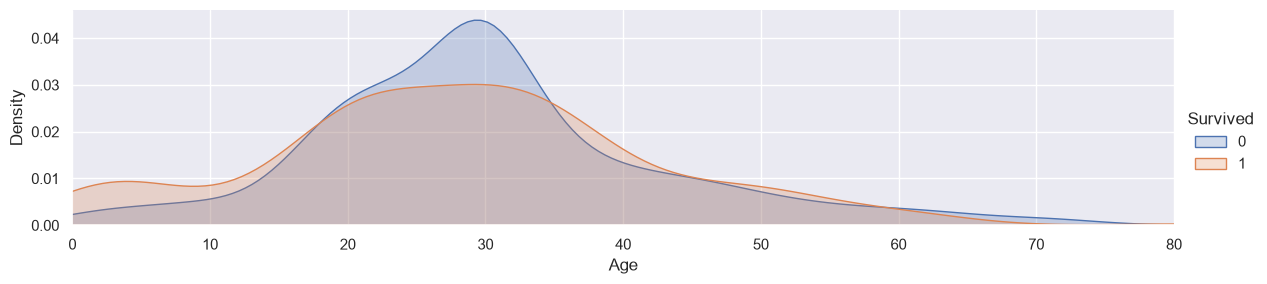

In [221]:
# Facetgrid 객체 생성(생존(1)/사망(0)), aspect =4: 가로 세로 비율
facet=sns.FacetGrid(train, hue="Survived", aspect=4)
facet.map(sns.kdeplot, 'Age', fill=True) # sns.kdeplot: 곡선 그래프 / shade = True: 셰이드 채움
facet.set(xlim=(0, train['Age'].max())) # x축 범위를 0 ~ 최대나이
facet.add_legend()
plt.show()

(0.0, 20.0)

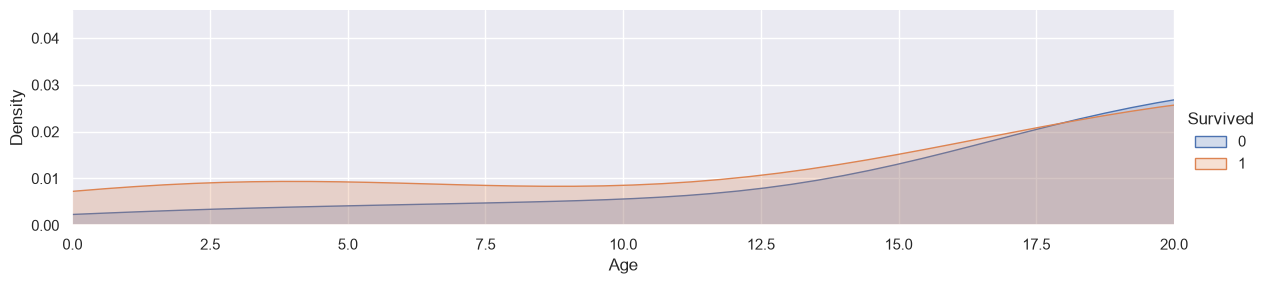

In [222]:
facet=sns.FacetGrid(train, hue="Survived", aspect=4)
facet.map(sns.kdeplot, 'Age', fill=True) 
facet.set(xlim=(0, train['Age'].max())) 
facet.add_legend()
plt.xlim(0,20)

(20.0, 40.0)

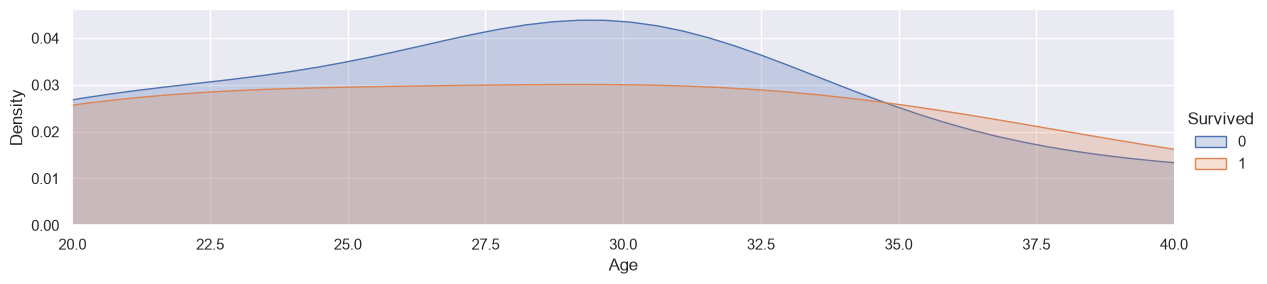

In [223]:
facet=sns.FacetGrid(train, hue="Survived", aspect=4)
facet.map(sns.kdeplot, 'Age', fill=True) 
facet.set(xlim=(0, train['Age'].max())) 
facet.add_legend()
plt.xlim(20,40)

(60.0, 80.0)

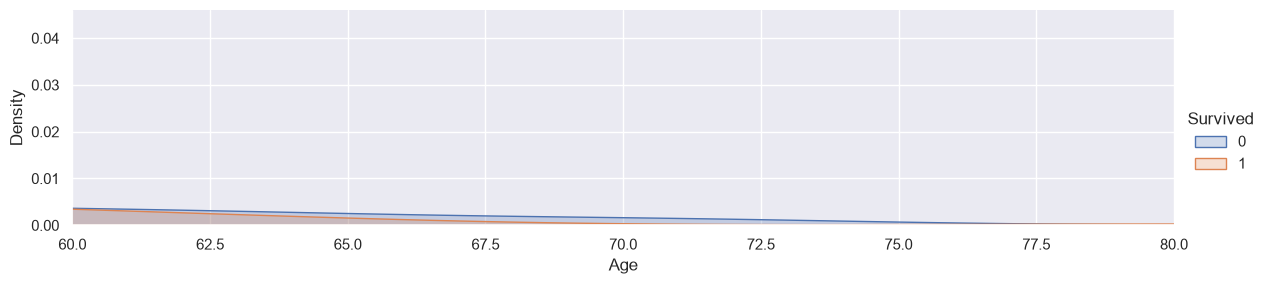

In [224]:
facet=sns.FacetGrid(train, hue="Survived", aspect=4)
facet.map(sns.kdeplot, 'Age', fill=True) 
facet.set(xlim=(0, train['Age'].max())) 
facet.add_legend()
plt.xlim(60)

## Binning

- feature vector map:
- child:0
- young:1
- adult:2
- mid-age:3
- senior:4

In [225]:
for dataset in train_test_data:
  dataset.loc[dataset['Age'] <= 16, 'Age']=0
  dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <=26), 'Age']=1
  dataset.loc[(dataset['Age'] > 26) & (dataset['Age'] <= 36), 'Age']=2
  dataset.loc[(dataset['Age'] > 36) & (dataset['Age'] <= 62), 'Age']=3
  dataset.loc[(dataset['Age'] > 62),  'Age']=4

In [226]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,1,3.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,2.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,2.0,0,0,373450,8.0500,NaN,S,0


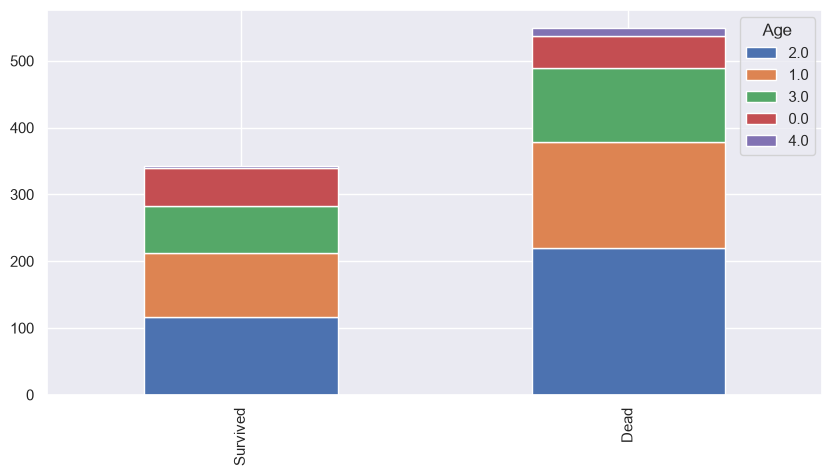

In [227]:
bar_chart('Age')

#### 4-4.Embarked 의 정보가 없으면 S로 대체
- S = Southampton(영국) 주로 3등석
- C = Cherbourg(프랑스) 주로 부유층
- Q = Queenstown(아일랜드) 승객 수 적음

In [228]:
# null값 전처리
for dataset in train_test_data:
    dataset['Embarked'] = dataset['Embarked'].fillna('S')

In [229]:
embarked_mapping = {"S":0, "C":1, "Q":2}
for dataset in train_test_data:
    dataset['Embarked'] = dataset['Embarked'].map(embarked_mapping)

In [230]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,7.2500,NaN,0,0
1,2,1,1,1,3.0,1,0,PC 17599,71.2833,C85,1,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1
3,4,1,1,1,2.0,1,0,113803,53.1000,C123,0,2
4,5,0,3,0,2.0,0,0,373450,8.0500,NaN,0,0


In [231]:
test.head(30)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,0,2.0,0,0,330911,7.8292,NaN,2,0
1,893,3,1,3.0,1,0,363272,7.0000,NaN,0,2
2,894,2,0,3.0,0,0,240276,9.6875,NaN,2,0
3,895,3,0,2.0,0,0,315154,8.6625,NaN,0,0
4,896,3,1,1.0,1,1,3101298,12.2875,NaN,0,2
5,897,3,0,0.0,0,0,7538,9.2250,NaN,0,0
6,898,3,1,2.0,0,0,330972,7.6292,NaN,2,1
7,899,2,0,1.0,1,1,248738,29.0000,NaN,0,0
8,900,3,1,1.0,0,0,2657,7.2292,NaN,1,2
9,901,3,0,1.0,2,0,A/4 48871,24.1500,NaN,0,0


#### 4-5. Fare

In [232]:
# Pclass의 그룹별 중간값을 Fare의 nan값에 대체
train['Fare'] = train['Fare'].fillna(train.groupby("Pclass")["Fare"].transform("median"))
test['Fare']=test['Fare'].fillna(test.groupby("Pclass")["Fare"].transform("median"))

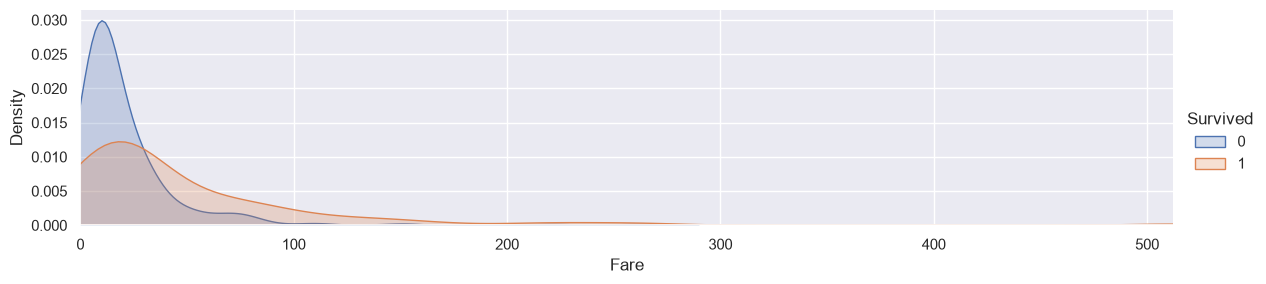

In [233]:
facet=sns.FacetGrid(train, hue="Survived", aspect=4)
facet.map(sns.kdeplot, 'Fare', fill=True) # sns.kdeplot: 곡선 그래프 / shade = True: 셰이드 채움
facet.set(xlim=(0, train['Fare'].max())) # x축 범위를 0 ~ 최대나이
facet.add_legend()
plt.show()

In [234]:
for dataset in train_test_data:
  dataset.loc[dataset['Fare'] <= 17, 'Fare']=0
  dataset.loc[(dataset['Fare'] > 17) & (dataset['Fare'] <=30), 'Fare']=1
  dataset.loc[(dataset['Fare'] > 30) & (dataset['Fare'] <= 100), 'Fare']=2
  dataset.loc[dataset['Fare'] > 100, 'Fare']=3

In [235]:
train.head(50)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,0.0,NaN,0,0
1,2,1,1,1,3.0,1,0,PC 17599,2.0,C85,1,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,0.0,NaN,0,1
3,4,1,1,1,2.0,1,0,113803,2.0,C123,0,2
4,5,0,3,0,2.0,0,0,373450,0.0,NaN,0,0
5,6,0,3,0,2.0,0,0,330877,0.0,NaN,2,0
6,7,0,1,0,3.0,0,0,17463,2.0,E46,0,0
7,8,0,3,0,0.0,3,1,349909,1.0,NaN,0,3
8,9,1,3,1,2.0,0,2,347742,0.0,NaN,0,2
9,10,1,2,1,0.0,1,0,237736,2.0,NaN,1,2


#### 4-6 Cabin

In [236]:
train.Cabin.value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [237]:
# 전처리 -> 첫글자만 추출
for dataset in train_test_data:
    dataset['Cabin'] = dataset['Cabin'].str[:1]

<Axes: >

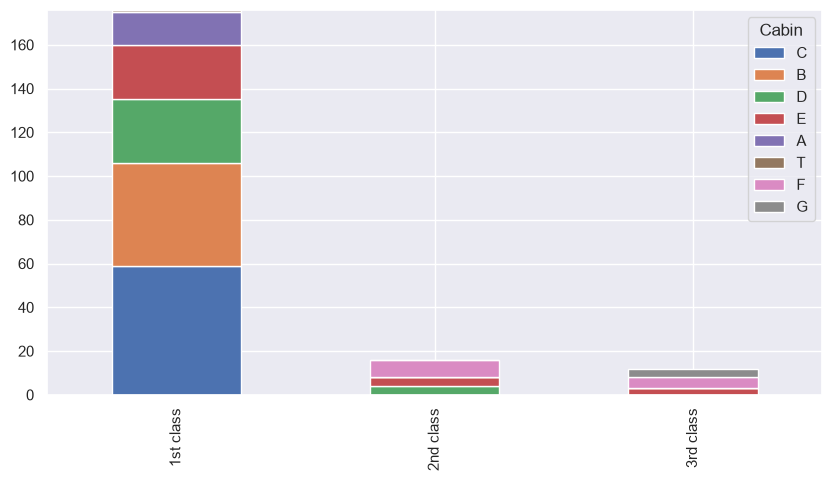

In [238]:
# 1등석은 Cabin정보가 많고 3등석은 거의 없음
Pclass1 = train[train['Pclass'] ==1]['Cabin'].value_counts()
Pclass2 = train[train['Pclass'] ==2]['Cabin'].value_counts()
Pclass3 = train[train['Pclass'] ==3]['Cabin'].value_counts()
df = pd.DataFrame([Pclass1,Pclass2,Pclass3])
df.index= ['1st class', '2nd class', '3rd class']
df.plot(kind='bar', stacked=True, figsize=(10,5))

In [239]:
# Cabin의 알파벳을 위치/계층적 의미를 고려하여 숫자 값으로 매핑
# 예: A는 고급 구역, G나 T는 하위 구역으로 볼 수 있음. T는 드문 케이스이지만 생존과의 관련성 분석에 유용할 수 있음
cabin_mapping = {"A": 0, "B": 0.4, "C": 0.8, "D": 1.2, "E": 1.6, "F": 2, "G": 2.4, "T": 2.8}
for dataset in train_test_data:
  dataset['Cabin']=dataset['Cabin'].map(cabin_mapping)

In [240]:
train['Cabin'] = train['Cabin'].fillna(train.groupby('Pclass')['Cabin'].transform('median'))
test['Cabin'] = test['Cabin'].fillna(test.groupby('Pclass')['Cabin'].transform('median'))

In [241]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,0.0,2.0,0,0
1,2,1,1,1,3.0,1,0,PC 17599,2.0,0.8,1,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,0.0,2.0,0,1
3,4,1,1,1,2.0,1,0,113803,2.0,0.8,0,2
4,5,0,3,0,2.0,0,0,373450,0.0,2.0,0,0


In [242]:
# 형제 + 부모 + 본인의 수를 합쳐서 하나의 FamilySize 변수로 생성
# 혼자 탄 사람(1) vs 가족과 함께 탄 사람의 생존률이 차이를 보임

train['FamilySize'] = train['SibSp']+train['Parch']+1
test['FamilySize'] = test['SibSp']+test['Parch']+1

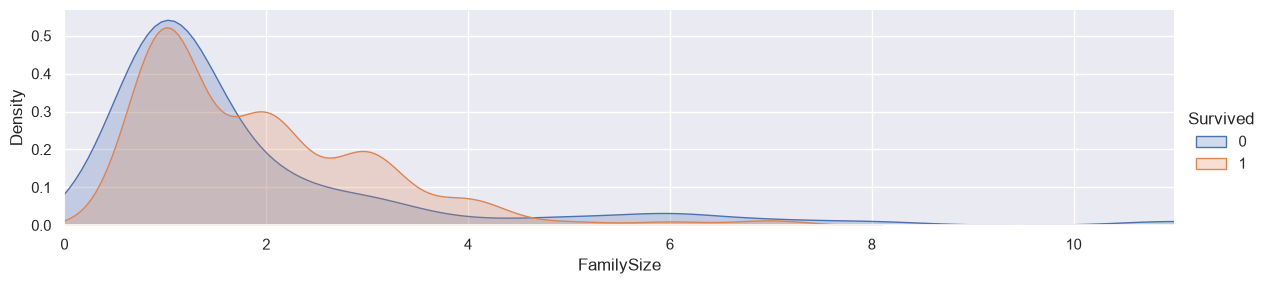

In [243]:
facet=sns.FacetGrid(train, hue="Survived", aspect=4)
facet.map(sns.kdeplot, 'FamilySize', fill=True) # sns.kdeplot: 곡선 그래프 / shade = True: 셰이드 채움
facet.set(xlim=(0, train['FamilySize'].max())) # x축 범위를 0 ~ 최대나이
facet.add_legend()
plt.show()

In [244]:
# 이미 벡터값이여서 스케일링 되어 반환 되지만, 값의 차이가 있음
# 일반적으로 중간 가족 규모 (2~4명)의 생존률이 가장 높았음
family_mapping={1:0.2, 2:0.4, 3: 0.8, 4: 1.2, 5: 1.6, 6: 2, 7: 2.4, 8: 2.8, 9: 3.2, 10: 3.6, 11: 4}
for dataset in train_test_data:
    dataset['FamilySize'] = dataset['FamilySize'].map(family_mapping)

In [245]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,0,1.0,1,0,A/5 21171,0.0,2.0,0,0,0.4
1,2,1,1,1,3.0,1,0,PC 17599,2.0,0.8,1,2,0.4
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,0.0,2.0,0,1,0.2
3,4,1,1,1,2.0,1,0,113803,2.0,0.8,0,2,0.4
4,5,0,3,0,2.0,0,0,373450,0.0,2.0,0,0,0.2


In [246]:
features_drop = ['SibSp','Parch','Ticket']
train = train.drop(features_drop, axis=1)
test = test.drop(features_drop, axis=1)

In [247]:
train_data = train.drop('Survived',axis=1)
target = train['Survived']

train_data.shape, target.shape

((891, 9), (891,))

In [248]:
train_data = train_data.drop('PassengerId', axis=1)

In [249]:
train_data.head()

,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,3,0,1.0,0.0,2.0,0,0,0.4
1,1,1,3.0,2.0,0.8,1,2,0.4
2,3,1,1.0,0.0,2.0,0,1,0.2
3,1,1,2.0,2.0,0.8,0,2,0.4
4,3,0,2.0,0.0,2.0,0,0,0.2


# 5. Modelling

In [250]:
# Classifire Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

import numpy as np

In [251]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,0,1.0,0.0,2.0,0,0,0.4
1,2,1,1,1,3.0,2.0,0.8,1,2,0.4
2,3,1,3,1,1.0,0.0,2.0,0,1,0.2
3,4,1,1,1,2.0,2.0,0.8,0,2,0.4
4,5,0,3,0,2.0,0.0,2.0,0,0,0.2


### 5-1. Cross Validation(k-fold) 교차검증
- 데이터를 여러 번 나누어 학습과 평가를 반복하면서 모델의 성능을 더 신뢰성 있게 측정하는 방법

In [252]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
# n_splits :반복횟수 10번 크로스 테스트/ shuffle=True : 분할하기전에 섞기 때문에 편중될 확률을 줄인다
# random_state : seed 자동생성
k_fold=KFold(n_splits=10, shuffle=True, random_state=0)
k_fold

KFold(n_splits=10, random_state=0, shuffle=True)

### 5-2 KNN

In [253]:
clf=KNeighborsClassifier(n_neighbors=13)
scoring='accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.8        0.78651685 0.84269663 0.83146067 0.85393258 0.83146067
 0.82022472 0.79775281 0.83146067 0.82022472]


In [254]:
round(np.mean(score)*100,2)

np.float64(82.16)

### 5-3 Decision Tree

In [255]:
clf=DecisionTreeClassifier()
scoring='accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.76666667 0.82022472 0.7752809  0.7752809  0.88764045 0.7752809
 0.83146067 0.82022472 0.74157303 0.79775281]


In [256]:
round(np.mean(score)*100,2)

np.float64(79.91)


### 5-3 Random Forest
-  여러개의 Decision Tree를 만들어서 다수결로 결정하여 예측

In [257]:
clf=RandomForestClassifier()
scoring='accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.82222222 0.82022472 0.79775281 0.75280899 0.8988764  0.80898876
 0.80898876 0.80898876 0.75280899 0.83146067]


In [258]:
round(np.mean(score)*100,2)

np.float64(81.03)

### 5-4 Navie Bayse Score

In [259]:
clf=GaussianNB()
scoring='accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.85555556 0.74157303 0.75280899 0.75280899 0.71910112 0.80898876
 0.75280899 0.79775281 0.86516854 0.84269663]


In [ ]:
round(np.mean(score)*100,2)

np.float64(78.89)

### 5-5 SVC

In [261]:
clf=SVC()
scoring='accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.83333333 0.79775281 0.83146067 0.82022472 0.84269663 0.82022472
 0.84269663 0.85393258 0.84269663 0.86516854]


In [263]:
round(np.mean(score)*100,2)

np.float64(83.5)

In [264]:
clf=SVC()
clf.fit(train_data, target)
test_data=test.drop("PassengerId", axis=1).copy()
prediction=clf.predict(test_data)

In [ ]:
submission=pd.DataFrame({"PassengerId": test["PassengerId"], "Survived":prediction})
submission.to_csv('../data/submission.csv', index=False)

In [268]:
submission=pd.read_csv('../data/submission.csv')
submission.head(20)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
